# Anatomy of the Rival Attack After a Turnover

**Analytics Cup 2.0 — Football, Defensive Positioning**

[Notebook 07](07_turnovers_cost_and_press.ipynb) showed *where* losing the ball costs the most. This
notebook asks the follow-up questions a coach would ask next: in which **exact lane** is it most
expensive; does it matter **how many rivals break forward and how they spread** (two down one side,
one central and one wide); whether the ball-winner **carries it or releases it**, and **how long** he
keeps it; whether it matters **who lost it** — and why the own-half **left flank** looked costlier
than the right.

### Pre-specified before looking at any outcome
To avoid finding patterns by trying many things, the feature list and the model were fixed first:

| feature | definition |
|---|---|
| `lane5` | loss lane: wide (\|y\|>20.16), half-space (9.16<\|y\|≤20.16), centre; left = the losing team's left |
| `lost_by` | position group of the player who lost the ball |
| `own_near`, `rival_near` | outfield players within 10 m of the ball at the loss |
| `goalside_2` | losing-team outfield players closer to their own goal than the ball, 2 s after the loss |
| `att_ahead_2`, `att_config_2` | rival outfield players closer to the losing goal than the ball at 2 s; how they spread over 3 equal-width lanes |
| `carried`, `time_on_ball` | the ball-winner's first possession: did he carry it (SkillCorner `carry`), and for how long |
| `progress_5s` | metres the ball got closer to the losing goal in the first 5 s |

Outcome: rival shot within 15 s, before the losing team touches the ball again. Only turnovers where
the rival actually controlled the ball (2,039) — immediate contested recoveries have no rival attack
to dissect. Anything decided *after* seeing results is labelled **exploratory** below.


In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
from mplsoccer import Pitch
from turnovers import load_or_build_turnovers, compute_turnover_outcomes, players_near_ball, load_player_roles

pd.set_option("display.width", 150)
plt.rcParams["figure.dpi"] = 110
DATA_DIR = "../../skillcorner-opendata/data/matches"
to, tr = load_or_build_turnovers(DATA_DIR, "../data/processed")
to = to[to["rival_controlled"]].copy()
tr = tr[tr["turnover_id"].isin(to["turnover_id"])]
d = to.merge(compute_turnover_outcomes(DATA_DIR, to), on="turnover_id").merge(players_near_ball(tr), on="turnover_id")
roles = load_player_roles(DATA_DIR)
print(f"rival-controlled turnovers: {len(d)} | shots within 15 s: {d['shot_15s'].sum()} | goals: {d['goal_15s'].sum()}")


rival-controlled turnovers: 2039 | shots within 15 s: 120 | goals: 16


## 1. Features

Event-based ones (the ball-winner's first possession, who lost it) and tracking-based ones (players relative to the ball and the goal).

In [2]:
first, lost = [], []
for mid, grp in d.groupby("match_id"):
    ev = pd.read_csv(f"{DATA_DIR}/{mid}/{mid}_dynamic_events.csv", low_memory=False, usecols=[
        "event_type", "end_type", "pass_outcome", "team_id", "player_id", "frame_start", "frame_end", "carry", "duration", "channel_start"])
    pp = ev[ev["event_type"] == "player_possession"]
    losses = pp[(pp["end_type"] == "possession_loss") | ((pp["end_type"] == "pass") & (pp["pass_outcome"] == "unsuccessful"))]
    for _, r in grp.iterrows():
        f = pp[(pp["frame_start"] == r["gain_frame"]) & (pp["team_id"] == r["gaining_team_id"])].head(1)
        if len(f):
            first.append({"turnover_id": r["turnover_id"], "carried": bool(f["carry"].iloc[0]), "time_on_ball": f["duration"].iloc[0], "rival_channel": f["channel_start"].iloc[0]})
        l = losses[(losses["team_id"] == r["losing_team_id"]) & (losses["frame_end"] <= r["gain_frame"])].sort_values("frame_end").tail(1)
        if len(l):
            lost.append({"turnover_id": r["turnover_id"], "match_id": mid, "lost_player_id": l["player_id"].iloc[0]})
d = d.merge(pd.DataFrame(first), on="turnover_id", how="left")
lp = pd.DataFrame(lost).merge(roles[["match_id", "player_id", "position_group"]], left_on=["match_id", "lost_player_id"], right_on=["match_id", "player_id"], how="left")
d = d.merge(lp[["turnover_id", "position_group"]].rename(columns={"position_group": "lost_by"}), on="turnover_id", how="left")

ay = d["loss_y"].abs()
side = np.where(d["loss_y"] > 0, "left", "right")
d["lane5"] = np.select([ay > 20.16, ay > 9.16], [np.char.add("wide ", side), np.char.add("half-space ", side)], "centre")
d["third"] = pd.cut(d["loss_x"], [-60, -17.5, 17.5, 60], labels=["own third", "middle third", "rival third"])

# the rival's channel is labelled from the RIVAL's point of view -> mirror it to check our lanes
mirror = {"wide_left": "wide right", "wide_right": "wide left", "half_space_left": "half-space right", "half_space_right": "half-space left", "center": "centre"}
print(f"validation - our lane vs SkillCorner's channel (mirrored): {(d['rival_channel'].map(mirror) == d['lane5']).mean():.1%} agreement")
print(f"rival first possession found: {d['carried'].notna().sum()} / {len(d)} | player who lost it found: {d['lost_by'].notna().sum()} / {len(d)}")


validation - our lane vs SkillCorner's channel (mirrored): 100.0% agreement
rival first possession found: 2039 / 2039 | player who lost it found: 2039 / 2039


In [3]:
def snapshot(t):
    s = tr[np.isclose(tr["t"], t)]
    b = s[s["role"] == "ball"][["turnover_id", "x", "y"]].rename(columns={"x": "bx", "y": "by"})
    p = s[(s["role"] != "ball") & ~s["is_goalkeeper"]].merge(b, on="turnover_id")
    p["closer_to_goal"] = np.hypot(p["x"] + 52.5, p["y"]) < np.hypot(p["bx"] + 52.5, p["by"])  # losing team's goal at x=-52.5
    return p, b

p0, b0 = snapshot(0.0)
p2, _ = snapshot(2.0)
_, b5 = snapshot(5.0)
count = lambda p, role, name: p[(p["role"] == role) & p["closer_to_goal"]].groupby("turnover_id").size().rename(name)
att = p2[(p2["role"] == "gaining") & p2["closer_to_goal"]].copy()
att["lane3"] = np.select([att["y"] > 11.33, att["y"] < -11.33], ["L", "R"], "C")
cfg = att.groupby("turnover_id").agg(att_ahead_2=("lane3", "size"), lanes_used=("lane3", "nunique"))
d = (d.merge(count(p2, "losing", "goalside_2"), on="turnover_id", how="left")
      .merge(count(p0, "losing", "goalside_0"), on="turnover_id", how="left")
      .merge(count(p0, "gaining", "att_ahead_0"), on="turnover_id", how="left")
      .merge(cfg, on="turnover_id", how="left"))
num = ["goalside_2", "goalside_0", "att_ahead_0", "att_ahead_2", "lanes_used"]
d[num] = d[num].fillna(0)
d["att_config_2"] = np.select([d["att_ahead_2"] == 0, d["att_ahead_2"] == 1, d["lanes_used"] == 1, d["lanes_used"] == 2],
                              ["0 ahead", "1 ahead", "2+ in one lane", "2+ across two lanes"], "2+ across three lanes")
dist = lambda b: np.hypot(b["bx"] + 52.5, b["by"])
prog = b0.assign(d0=dist(b0))[["turnover_id", "d0"]].merge(b5.assign(d5=dist(b5))[["turnover_id", "d5"]], on="turnover_id")
d = d.merge(prog.assign(progress_5s=prog["d0"] - prog["d5"])[["turnover_id", "progress_5s"]], on="turnover_id", how="left")
d["shot"] = d["shot_15s"].astype(int)
d[["lane5", "lost_by", "own_near", "goalside_2", "att_ahead_2", "att_config_2", "carried", "time_on_ball", "progress_5s"]].describe(include="all").T[["count", "unique", "top", "mean"]]


,count,unique,top,mean
lane5,2039,5,centre,NaN
lost_by,2039,6,Midfield,NaN
own_near,2039.0,NaN,NaN,2.260912
goalside_2,2039.0,NaN,NaN,6.575282
att_ahead_2,2039.0,NaN,NaN,4.807749
att_config_2,2039,5,2+ across two lanes,NaN
carried,2039,2,True,NaN
time_on_ball,2039.0,NaN,NaN,1.573565
progress_5s,2030.0,NaN,NaN,7.060412


## 2. The 'mini-zones': third × lane

Shot conceded within 15 s by the exact lane and third where the ball was lost.

third                            own third              middle third              rival third
lane5                                                                                        
wide left         18.6% [11.2%-29.2%] n=70    4.4% [2.2%-8.4%] n=182   2.6% [1.0%-6.5%] n=154
half-space left     9.1% [3.9%-19.6%] n=55   6.1% [3.3%-10.8%] n=165   1.2% [0.3%-4.4%] n=160
centre            28.3% [17.3%-42.5%] n=46  10.1% [6.5%-15.4%] n=178   2.0% [0.9%-4.2%] n=305
half-space right  20.4% [11.8%-32.9%] n=54  10.6% [6.5%-16.7%] n=142   0.6% [0.1%-3.3%] n=170
wide right          6.2% [2.5%-15.0%] n=64    4.0% [1.9%-8.0%] n=176   2.5% [0.9%-7.2%] n=118


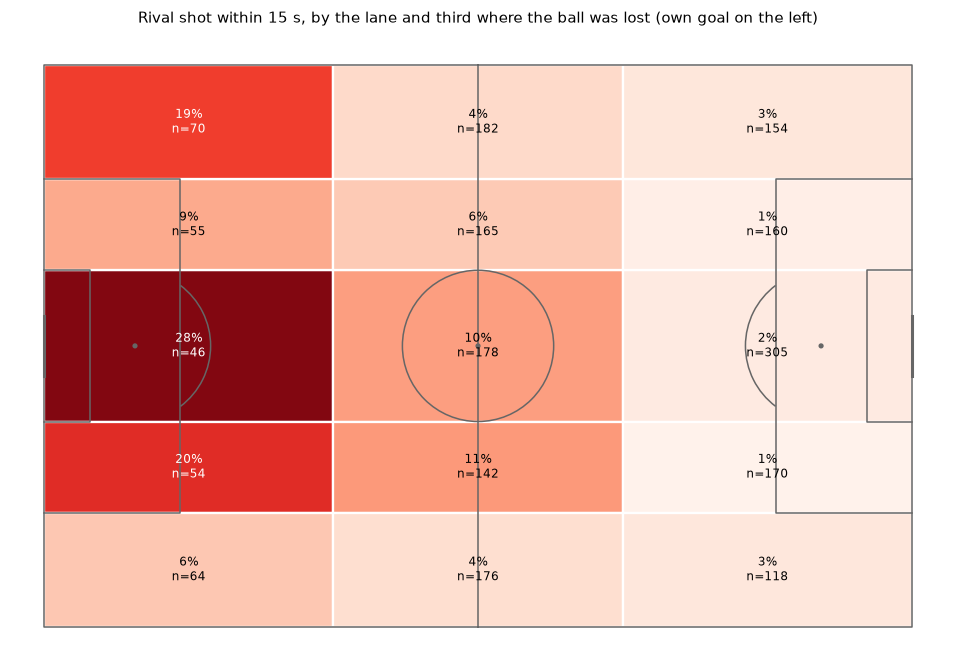

In [4]:
def rate(s):
    k, n = int(s.sum()), len(s)
    lo, hi = proportion_confint(k, n, method="wilson")
    return f"{k/n:5.1%} [{lo:4.1%}-{hi:4.1%}] n={n}"

lanes = ["wide left", "half-space left", "centre", "half-space right", "wide right"]
grid = d.groupby(["third", "lane5"], observed=True)["shot_15s"].agg(["mean", "size"])
print(d.groupby(["third", "lane5"], observed=True)["shot_15s"].apply(rate).unstack(0).reindex(lanes).to_string())

y_edges = {"wide left": (20.16, 34), "half-space left": (9.16, 20.16), "centre": (-9.16, 9.16), "half-space right": (-20.16, -9.16), "wide right": (-34, -20.16)}
x_edges = {"own third": (-52.5, -17.5), "middle third": (-17.5, 17.5), "rival third": (17.5, 52.5)}
fig, ax = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68, line_color="#666666", linewidth=1, line_zorder=3).draw(figsize=(10, 6.2))
for (third, lane), row in grid.iterrows():
    (x0, x1), (y0, y1) = x_edges[third], y_edges[lane]
    colour = plt.get_cmap("Reds")(min(row["mean"] / 0.30, 1.0)) if row["size"] >= 30 else "#eeeeee"
    ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, facecolor=colour, edgecolor="white", linewidth=1.5, zorder=1))
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, f"{row['mean']:.0%}\nn={int(row['size'])}", ha="center", va="center", fontsize=8, zorder=4,
            color="white" if row["mean"] / 0.30 > 0.6 else "black")
ax.set_title("Rival shot within 15 s, by the lane and third where the ball was lost (own goal on the left)", fontsize=10)
plt.show()


* **Rival third:** the lanes barely differ (≈1–3%) — losing it high is cheap wherever it happens.
* **Middle third:** the **central corridor** (centre + both half-spaces, ≈6–11%) costs roughly **twice**
  the wide lanes (≈4%). This is the most reliable lane pattern: large samples on every lane.
* **Own third:** the spread is large (≈6% to 28%) and the **centre is the costliest** lane, but each
  cell holds only 46–70 losses, and the rest of the pattern zig-zags (right half-space high, left
  half-space low — the opposite of the flanks). A zig-zag like that is what noise looks like in small
  cells, so beyond "centre worst", the own-third lane ordering shouldn't be read as a rule.

The third still dominates: every own-third lane is costlier than any rival-third lane.

## 3. One feature at a time — and why it misleads

In [5]:
for col in ["att_config_2", "lost_by", "carried"]:
    print(d.groupby(col, observed=True)["shot_15s"].apply(rate).to_string(), "\n")
for col, bins in [("goalside_2", [-1, 4, 6, 8, 11]), ("time_on_ball", [-0.1, 0.5, 1.5, 3, 60])]:
    print(d.groupby(pd.cut(d[col], bins), observed=True)["shot_15s"].apply(rate).to_string(), "\n")


att_config_2
0 ahead                   20.3% [12.9%-30.4%] n=79
1 ahead                  16.8% [11.7%-23.4%] n=155
2+ across three lanes       3.3% [1.9%-5.6%] n=393
2+ across two lanes        4.0% [3.0%-5.2%] n=1226
2+ in one lane             8.6% [5.4%-13.5%] n=186 

lost_by
Center Forward        3.7% [2.1%-6.5%] n=298
Central Defender     7.6% [5.1%-11.1%] n=303
Full Back             4.8% [3.2%-7.4%] n=413
Midfield              7.1% [5.1%-9.7%] n=496
Other                16.7% [8.3%-30.6%] n=42
Wide Attacker         4.9% [3.3%-7.2%] n=487 

carried
False     4.9% [3.7%-6.4%] n=1009
True      6.9% [5.5%-8.6%] n=1030 

goalside_2
(-1, 4]    14.9% [11.9%-18.6%] n=436
(4, 6]        6.0% [4.3%-8.3%] n=548
(6, 8]        3.0% [1.9%-5.0%] n=492
(8, 11]       1.2% [0.6%-2.5%] n=563 

time_on_ball
(-0.1, 0.5]      5.4% [4.1%-7.2%] n=832
(0.5, 1.5]       4.6% [3.0%-6.9%] n=459
(1.5, 3.0]      7.3% [5.1%-10.4%] n=381
(3.0, 60.0]     7.1% [4.9%-10.2%] n=367 



Read literally, "no rival ahead of the ball" (20%) would be *more* dangerous than "2+ rivals across
three lanes" (3%), and centre-backs would lose the costliest balls. Both are **location in disguise**:
when the ball is lost near your own goal, no rival can be closer to the goal than the ball, few of
your own players can be either, and it's defenders who lose balls there. Single-feature tables mix
all of that up; the model below separates it.

## 4. All pre-specified features together

In [6]:
m = d.dropna(subset=["carried", "time_on_ball", "progress_5s", "lost_by"]).assign(carried=lambda x: x["carried"].astype(int))
f = ("shot ~ loss_x + I(loss_y**2) + own_near + rival_near + goalside_2 + att_ahead_2 + C(lanes_used) "
     "+ carried + time_on_ball + progress_5s + C(lost_by, Treatment('Midfield'))")
r = smf.logit(f, data=m).fit(disp=0)
print(f"n={len(m)}, shots={m['shot'].sum()}")
pd.DataFrame({"odds_ratio": np.exp(r.params), "ci_low": np.exp(r.conf_int()[0]), "ci_high": np.exp(r.conf_int()[1]), "p": r.pvalues}).drop("Intercept").round(3)


n=2030, shots=119


,odds_ratio,ci_low,ci_high,p
C(lanes_used)[T.1.0],1.320,0.607,2.868,0.484
C(lanes_used)[T.2.0],1.151,0.455,2.914,0.766
C(lanes_used)[T.3.0],1.888,0.569,6.266,0.299
"C(lost_by, Treatment('Midfield'))[T.Center Forward]",0.616,0.287,1.324,0.215
"C(lost_by, Treatment('Midfield'))[T.Central Defender]",0.775,0.415,1.448,0.424
"C(lost_by, Treatment('Midfield'))[T.Full Back]",0.895,0.474,1.691,0.733
"C(lost_by, Treatment('Midfield'))[T.Other]",1.850,0.644,5.315,0.253
"C(lost_by, Treatment('Midfield'))[T.Wide Attacker]",0.856,0.470,1.561,0.613
loss_x,0.943,0.932,0.955,0.000
I(loss_y ** 2),0.999,0.998,0.999,0.001


Only **where the ball was lost** and **how fast the ball then moved towards goal** (`progress_5s`)
stand out. The second is barely an explanation — an attack that advanced quickly is, almost by
definition, a dangerous one — and because it sits *downstream* of everything else, it also soaks up
the effect of anything that works through it. No attack-shape, carry/pass or who-lost-it variable
adds a detectable signal. With ~120 shots and ~17 parameters the model is also near its limit
(about 7 events per parameter), so "not detectable" is the honest wording, not "no effect".

## 5. Exploratory: do the numbers matter within a zone?

*Designed after seeing section 4.* Within a single third, the counts at 2 s do come out strongly
"significant" — but in a direction that makes no football sense:

In [7]:
for th in ["own third", "middle third"]:
    z = d[d["third"] == th]
    for v in ["goalside_2", "att_ahead_2"]:
        rr = smf.logit(f"shot ~ {v} + loss_x + I(loss_y**2)", data=z).fit(disp=0)
        print(f"{th:12s} {v:11s} OR={np.exp(rr.params[v]):.2f} p={rr.pvalues[v]:.3f}")


own third    goalside_2  OR=0.66 p=0.000
own third    att_ahead_2 OR=0.65 p=0.000


middle third goalside_2  OR=0.75 p=0.000
middle third att_ahead_2 OR=0.73 p=0.000


*More* rival attackers ahead of the ball comes out *protective*, exactly like more defenders. Both
counts measure the same thing: how many players are between the ball and the goal, i.e. **where the
ball is at 2 s** — how far the attack has already progressed. The clean way to ask "do the numbers
matter" is the **balance** (defenders minus attackers between ball and goal) **at the moment of the
loss**, before the attack has moved:

In [8]:
d["balance_0"] = d["goalside_0"] - d["att_ahead_0"]
for th in ["own third", "middle third"]:
    z = d[d["third"] == th]
    rr = smf.logit("shot ~ balance_0 + loss_x + I(loss_y**2)", data=z).fit(disp=0)
    print(f"{th:12s} balance at the loss: OR={np.exp(rr.params['balance_0']):.2f} p={rr.pvalues['balance_0']:.2f}")
    print(z.groupby(pd.cut(z["balance_0"], [-20, 1, 3, 5, 20], labels=["<=1", "2-3", "4-5", "6+"]), observed=True)["shot_15s"].agg(["mean", "size"]).round(3).T.to_string(), "\n")


own third    balance at the loss: OR=0.90 p=0.41
balance_0     <=1      2-3     4-5
mean         0.17    0.154   0.152
size       100.00  156.000  33.000 



middle third balance at the loss: OR=1.06 p=0.65
balance_0      <=1      2-3     4-5
mean         0.065    0.074   0.048
size       370.000  431.000  42.000 



Flat. Within a zone, the numerical balance at the moment of the loss doesn't predict whether the
rival shoots. (This is not in tension with Notebook 07: teammates close to the ball help **win it
back**; once the rival has it and is away, the snapshot balance doesn't separate dangerous attacks
from harmless ones.)

In [9]:
z = d[d["third"] == "middle third"]
rr = smf.logit("shot ~ carried + loss_x + I(loss_y**2)", data=z.assign(carried=z["carried"].astype(int))).fit(disp=0)
print(f"middle third: ball-winner carries it -> OR={np.exp(rr.params['carried']):.2f}, p={rr.pvalues['carried']:.3f}")


middle third: ball-winner carries it -> OR=1.80, p=0.037


One weak exception: in the middle third, a ball-winner who **carries** the ball (rather than
releasing it) is followed by a shot somewhat more often. It is one of several within-zone checks, at
p≈0.04 — treat it as a lead, not a finding.

## 6. The left flank (hypothesis carried over from Notebook 07)

Own-half flank losses, left vs right: same situation, different outcome? Every measurable feature of
the situation is compared side by side.

In [10]:
fl = d[(d["loss_x"] < 0) & (d["loss_y"].abs() > 20.16)].copy()
fl["flank"] = np.where(fl["loss_y"] > 0, "left", "right")
cols = ["shot", "loss_x", "own_near", "rival_near", "goalside_0", "goalside_2", "att_ahead_2", "carried", "time_on_ball", "progress_5s"]
t = fl.groupby("flank")[cols].mean().T
t["p (Mann-Whitney)"] = [stats.mannwhitneyu(fl.loc[fl["flank"] == "left", c].astype(float), fl.loc[fl["flank"] == "right", c].astype(float)).pvalue for c in cols]
print(f"n: left {(fl['flank'] == 'left').sum()}, right {(fl['flank'] == 'right').sum()}")
t.round(3)


n: left 151, right 154


flank,left,right,p (Mann-Whitney)
shot,0.126,0.045,0.012
loss_x,-17.573,-16.338,0.500
own_near,2.391,2.221,0.234
rival_near,2.702,2.656,0.709
goalside_0,7.146,6.740,0.068
goalside_2,6.464,6.318,0.472
att_ahead_2,4.477,4.292,0.599
carried,0.523,0.545,0.698
time_on_ball,1.403,1.779,0.319
progress_5s,5.064,3.829,0.422


In [11]:
rows = []
for mid, g in fl.groupby("match_id"):
    ev = pd.read_csv(f"{DATA_DIR}/{mid}/{mid}_dynamic_events.csv", low_memory=False, usecols=["event_type", "end_type", "team_id", "frame_end", "x_end", "y_end", "penalty_area_end", "lead_to_goal"])
    sh = ev[(ev["event_type"] == "player_possession") & (ev["end_type"] == "shot")]
    for _, r in g.iterrows():
        lim = r["gain_frame"] + min(150, r["regain_s"] * 10 if np.isfinite(r["regain_s"]) else 150)
        for _, q in sh[(sh["team_id"] == r["gaining_team_id"]) & (sh["frame_end"] >= r["gain_frame"]) & (sh["frame_end"] <= lim)].iterrows():
            rows.append({"flank": r["flank"], "distance_m": np.hypot(52.5 - q["x_end"], q["y_end"]), "inside_box": bool(q["penalty_area_end"]), "goal": bool(q["lead_to_goal"])})
ends = pd.DataFrame(rows)
ends.groupby("flank").agg(shots=("distance_m", "size"), goals=("goal", "sum"), median_distance_m=("distance_m", "median"), share_inside_box=("inside_box", "mean")).round(2)


,shots,goals,median_distance_m,share_inside_box
flank,,,,
left,20,4,20.95,0.45
right,7,1,12.21,1.00


The two flanks are **indistinguishable on every measured feature** — location, players near the
ball, goal-side defenders, rival runners, carrying, time on the ball, speed of progression. The left
produces more shots, but more than half of them from **outside the box** (median ~21 m, vs ~12 m and
all inside the box on the right); the goal counts (4 vs 1) are far too small to mean anything.

**Verdict:** a post-hoc pattern with no mechanism and lower-quality extra shots is most likely noise.
A factor the data doesn't record (e.g. footedness of the players involved) can't be ruled out, but
nothing here supports turning it into advice.

## 7. Summary

| Question | Answer from 20 matches |
|---|---|
| Which exact lane is costliest? | The **third** dominates; within it, the **central corridor** is costliest in the middle third (~2× the wings) and the centre in the own third; finer own-third lane differences look like noise |
| Does the rival's attack shape (how many, how spread) matter? | Not detectably, once the zone is fixed |
| Does the numerical balance at the loss matter? | Not for shots conceded (it does help **winning the ball back** — Notebook 07) |
| Carry vs release, time on the ball? | Weak lead only: carrying after winning it in the middle third (p≈0.04, exploratory) |
| Does it matter who lost it? | Not once location is accounted for |
| Left flank costlier? | Unexplained, lower-quality extra shots — most likely noise |

**The consistent message across Notebooks 06–08:** the danger of a turnover is decided overwhelmingly
by *where* it happens. The finer tactical anatomy we can measure — attack shape, numbers, carry vs
pass — doesn't add a detectable signal in this sample. The defending team's levers that do show up
are about **not losing the ball in the costly zones** and **having teammates close enough to win it
straight back**.

### Limitations
~120 shots across 2,039 turnovers limits what a multivariable model can detect; "not detectable" is
not "no effect". Several analyses here were designed after seeing results and are labelled
exploratory. One league, 20 matches, broadcast tracking.
